# Sentinel-2 NDVI extraction with AerEO

This chapter extends the Sentinel-2 L2A pipeline by computing the **Normalized Difference Vegetation Index (NDVI)** as a preprocessing step.

$$
\text{NDVI} = \frac{NIR - RED}{NIR + RED}
$$

Sentinel-2 provides both bands at 10 m resolution, so the index can be computed directly from the L2A surface reflectance product without resampling.


## Environment setup

The first cell installs AerEO and any required plugins. If you are reading the rendered book or running on Binder, where the environment is already prepared, `pip` will report that the requirements are satisfied and skip the download.


In [ ]:
# Install AerEO and any required plugins for this notebook (Google Colab)
!pip install -q "aereo[viz]"

## Config used in this notebook

This notebook loads the job from `config/job_sentinel2-ndvi.yaml`. It uses Hydra composition to extend `job_sentinel2.yaml` and only adds an NDVI preprocess stage:

```yaml
defaults:
  - job_sentinel2
  - _self_

name: sentinel2_ndvi
preprocess:
  - _target_: aereo.builtins.ndvi
    _partial_: true
    ndvi_nir_band: nir
    ndvi_red_band: red
```

The `defaults` list tells Hydra to merge `job_sentinel2.yaml` first, then apply the overrides in this file. This lets you define one base sensor config and create many derived products with only a few lines of YAML.


In [ ]:
# Download config files and AOIs from the GitHub repository so this
# notebook can run outside the repo (e.g. Google Colab).
import os
import urllib.request

GITHUB_RAW = "https://raw.githubusercontent.com/frandorr/aereo/main"

os.makedirs("config/aoi", exist_ok=True)

# Config files
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/job_sentinel2.yaml",
    "config/job_sentinel2.yaml",
)
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/job_sentinel2-ndvi.yaml",
    "config/job_sentinel2-ndvi.yaml",
)

# AOI files
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/aoi/chocon.geojson",
    "config/aoi/chocon.geojson",
)

## Loading the job

`ExtractionJob.load_from_config()` parses the YAML with [Hydra](https://hydra.cc/), resolves every `_target_` callable, and validates the resulting `ExtractionJob`. The `config_name` argument is the YAML filename without extension, and `config_dir` is the folder that contains it.

A job is a declarative bundle of pipeline steps. Once loaded, the same job can be searched, can have tasks built from it, and can be executed.


In [1]:
from aereo.cache import TaskResultCache
from aereo.executors import LocalExecutor
from aereo.pipeline import ExtractionJob

# Load the job from the Hydra config package.
job = ExtractionJob.load_from_config(
    config_dir="config",
    config_name="job_sentinel2-ndvi",
)
assets = job.search()  # Use the search method from the job object to get the assets.
tasks = job.build_tasks(assets)
len(tasks)

2026-07-08 14:48:07 [info     ] search_called                  provider=search_stac
2026-07-08 14:48:09 [info     ] build_tasks_start              assets=16 builder=build_grouped_tasks


8

## The executor

AerEO separates *what* to run (the tasks) from *how* to run them. `LocalExecutor` runs tasks on the local machine. The `workers` argument controls parallelism, and `use_threads=True` uses a threading backend, which is a good default for I/O-bound COG readers.


In [2]:
# now we create an Executor, in this case a LocalExecutor to run
# each ExtractionTask using Threads
local_exec = LocalExecutor(workers=-1, use_threads=True, cache=TaskResultCache())

## Running the extraction

`job.execute(tasks, executor=...)` hands the prepared tasks to the executor. The executor runs each task independently; inside every task AerEO performs the pipeline:

```text
read -> preprocess -> reproject -> postprocess -> write
```

The returned object is a GeoDataFrame of **artifacts** — one row per output GeoTIFF with its metadata, CRS, and footprint.


In [3]:
# Extract!
print("Extracting...")
artifacts = job.execute(tasks, executor=local_exec)
print(f"✓ Extracted {len(artifacts)} artifacts")

Extracting...
2026-07-08 14:48:09 [info     ] execute_start                  executor=LocalExecutor task_count=8
✓ Extracted 56 artifacts


## Visualizing NDVI

`plot_artifact_patches` is called with the `RdYlGn` colormap, a common choice for vegetation indices: red for low NDVI (water, shadows, bare soil), yellow for sparse vegetation, and green for healthy vegetation.


(<Figure size 2000x1495.93 with 2 Axes>,
 <Axes: title={'center': 'Extracted Patches Spatial Overview'}, xlabel='UTM X', ylabel='UTM Y'>)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


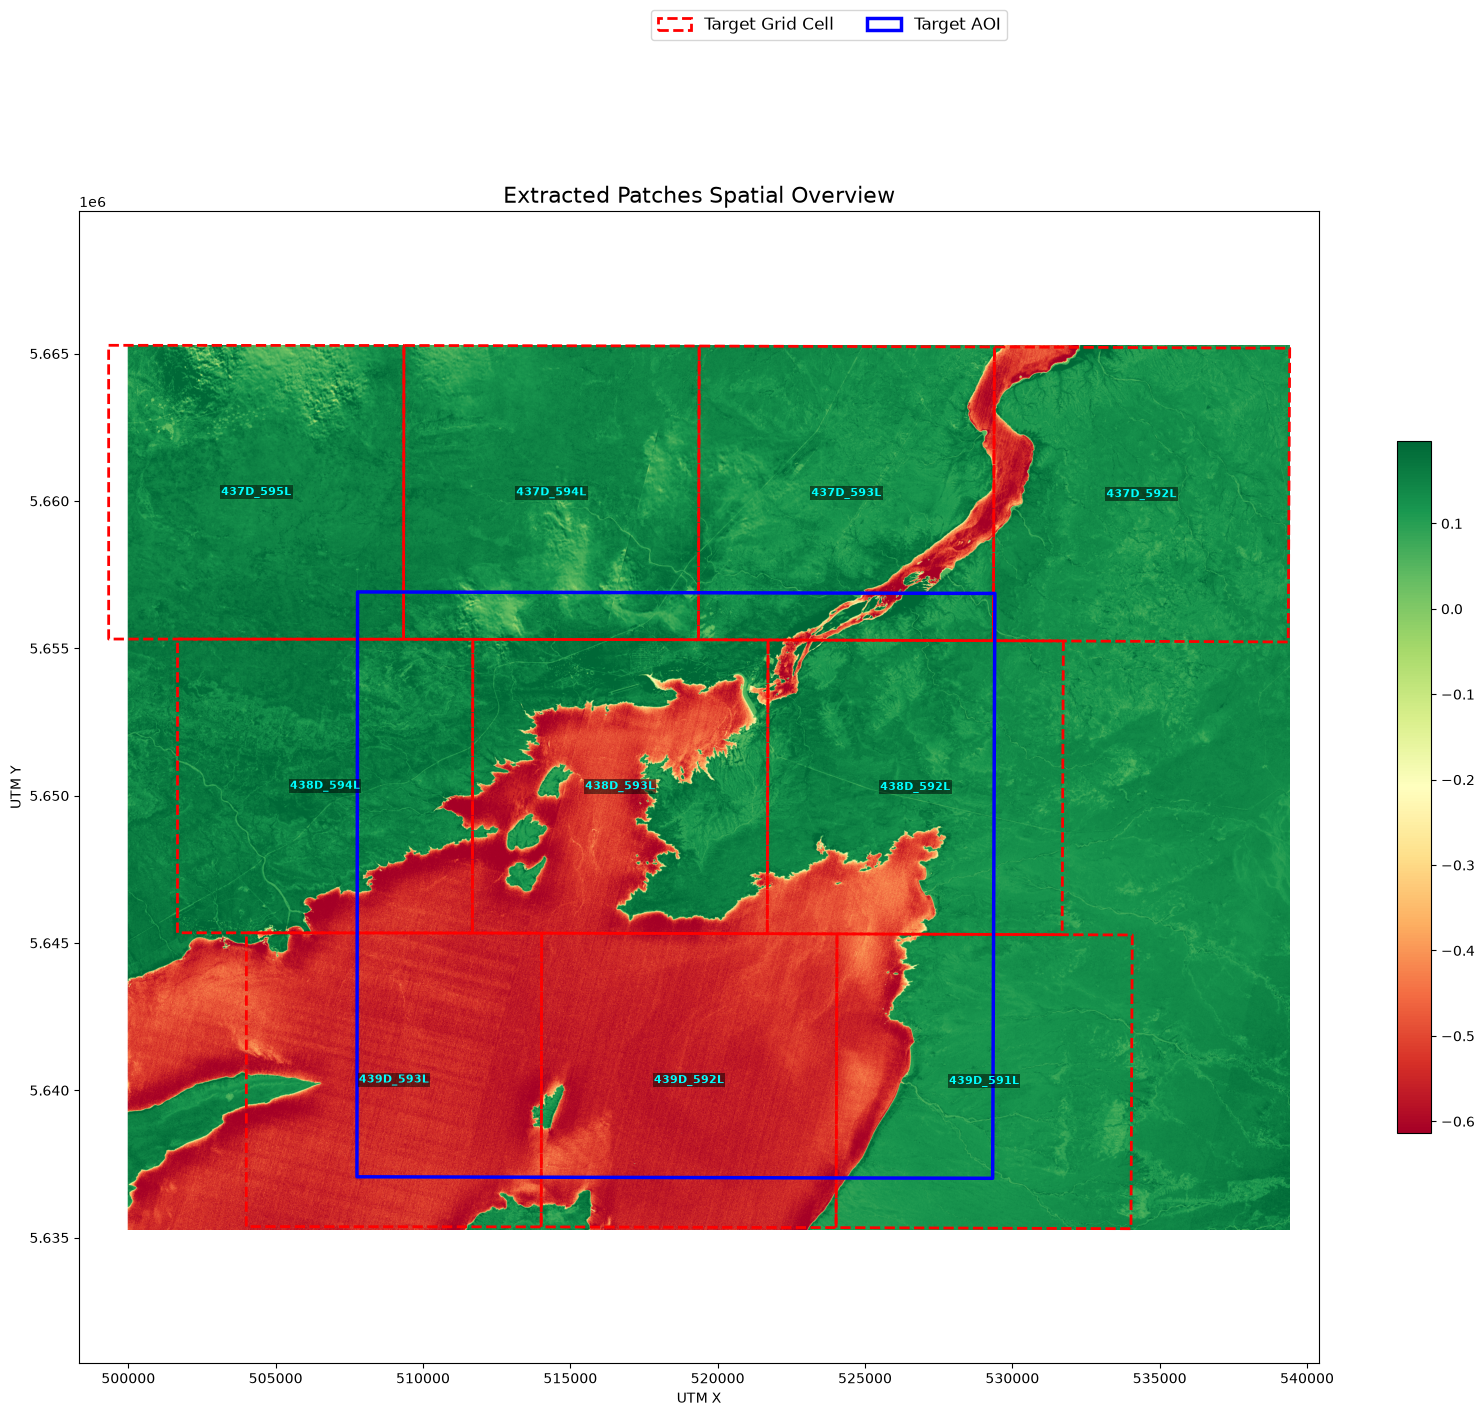

In [5]:
from aereo.viz import plot_artifact_patches

plot_artifact_patches(
    artifacts,
    ds_factor=1,
    cmap="RdYlGn",
    stretch="percentile",
    aoi=job.target_aoi,
    aoi_edgecolor="blue",
)